In [1]:
# Standard imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings

# Loading sklearn functionality
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay



In [2]:
# Set a consistent seed
seed = 42
np.random.seed(seed)

"""
Note: Suppressing warnings is generally not recommended.
Warnings are being ignored in this notebook to prevent unnecessary clutter
and improve readability while working with the dataset.
"""

filterwarnings(action='ignore')

In [3]:
# Load the dataset
churn_df = pd.read_csv(r"D:\BrainStation\BrainStation_DataScience\0PROJECTS\Ryan_Austin_Unit3_Deliverable2\Telco-Customer-Churn.csv")



### TABLE OF CONTENTS

###### 1. Exploratory Data Analysis
###### 2. Feature Engineering and Selection
###### 3. Machine Learning Model Selection and Implementation
###### 4. Model Evaluation
###### 5. Conclusions

### 1. Exploratory Data Analysis
##### Use EDA to see which features are the strongest predictors of churn, which are redundant, etc.

In [4]:
# Create a working copy of the dataset
churn_df2 = churn_df.copy()

##### Feature Information
churn_df2.info()
churn_df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              7043 non-null   int64  
 1   Customer ID             7043 non-null   object 
 2   Gender                  7043 non-null   object 
 3   Age                     7043 non-null   int64  
 4   Senior Citizen          7043 non-null   object 
 5   Married                 7043 non-null   object 
 6   Dependents              7043 non-null   object 
 7   Tenure in Months        7043 non-null   int64  
 8   Phone Service           7043 non-null   object 
 9   Multiple Lines          7043 non-null   object 
 10  Internet Service        7043 non-null   object 
 11  Online Security         7043 non-null   object 
 12  Online Backup           7043 non-null   object 
 13  Device Protection Plan  7043 non-null   object 
 14  Premium Tech Support    7043 non-null   

,Unnamed: 0,Customer ID,Gender,Age,Senior Citizen,Married,Dependents,Tenure in Months,Phone Service,Multiple Lines,...,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charge,Total Charges,Churn
0,0,8779-QRDMV,Male,78,Yes,No,No,1,No,No,...,Yes,No,No,Yes,Month-to-Month,Yes,Bank Withdrawal,39.65,39.65,Yes
1,1,7495-OOKFY,Female,74,Yes,Yes,Yes,8,Yes,Yes,...,No,No,No,No,Month-to-Month,Yes,Credit Card,80.65,633.30,Yes
2,2,1658-BYGOY,Male,71,Yes,No,Yes,18,Yes,Yes,...,No,No,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,95.45,1752.55,Yes
3,3,4598-XLKNJ,Female,78,Yes,Yes,Yes,25,Yes,No,...,Yes,No,Yes,Yes,Month-to-Month,Yes,Bank Withdrawal,98.50,2514.50,Yes
4,4,4846-WHAFZ,Female,80,Yes,Yes,Yes,37,Yes,Yes,...,No,No,No,No,Month-to-Month,Yes,Bank Withdrawal,76.50,2868.15,Yes


In [5]:
##### Search for and remove null values
churn_df2.isna().sum().sum()

# There were no null values found.

0

In [6]:
##### Searcj fpr and remove duplicates
churn_df2.duplicated().sum()

# There were no duplicated values found.

0

In [7]:
# Convert the variables into counts
churn_counts_df = churn_df2.Churn.value_counts()
churn_counts_df

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

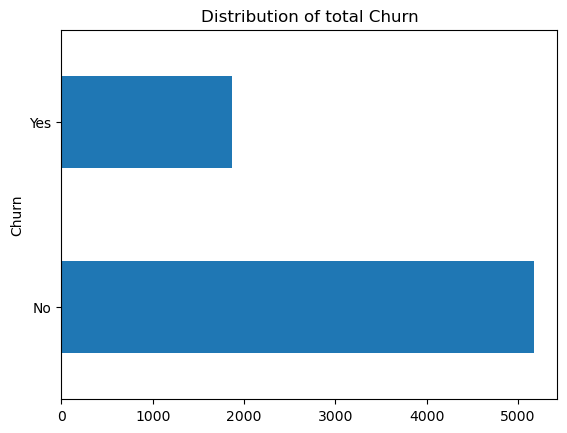

In [8]:
# Plot the overal churn distribution
plot = churn_counts_df.plot(kind='barh', title=f"Distribution of total Churn")
plt.show

In [9]:
churn_cat_df = churn_df2.drop(['Unnamed: 0', 'Customer ID', 'Age', 'Tenure in Months', 'Monthly Charge', 'Total Charges'], axis=1)
# It is more efficient to create a sub-frame of only categorical features by simply dropping the numerical features, which number much fewer. 
churn_cat_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  7043 non-null   object
 1   Senior Citizen          7043 non-null   object
 2   Married                 7043 non-null   object
 3   Dependents              7043 non-null   object
 4   Phone Service           7043 non-null   object
 5   Multiple Lines          7043 non-null   object
 6   Internet Service        7043 non-null   object
 7   Online Security         7043 non-null   object
 8   Online Backup           7043 non-null   object
 9   Device Protection Plan  7043 non-null   object
 10  Premium Tech Support    7043 non-null   object
 11  Streaming TV            7043 non-null   object
 12  Streaming Movies        7043 non-null   object
 13  Contract                7043 non-null   object
 14  Paperless Billing       7043 non-null   object
 15  Paym

In [10]:
groupby_churn_df = {}

for col in churn_cat_df.columns:
    if col != 'Churn':
        groupby_churn_df[col] = churn_cat_df.groupby('Churn')[col].value_counts()

groupby_churn_df
    

{'Gender': Churn  Gender
 No     Male      2625
        Female    2549
 Yes    Female     939
        Male       930
 Name: count, dtype: int64,
 'Senior Citizen': Churn  Senior Citizen
 No     No                4508
        Yes                666
 Yes    No                1393
        Yes                476
 Name: count, dtype: int64,
 'Married': Churn  Married
 No     Yes        2733
        No         2441
 Yes    No         1200
        Yes         669
 Name: count, dtype: int64,
 'Dependents': Churn  Dependents
 No     No            3653
        Yes           1521
 Yes    No            1763
        Yes            106
 Name: count, dtype: int64,
 'Phone Service': Churn  Phone Service
 No     Yes              4662
        No                512
 Yes    Yes              1699
        No                170
 Name: count, dtype: int64,
 'Multiple Lines': Churn  Multiple Lines
 No     No                3053
        Yes               2121
 Yes    No                1019
        Yes          

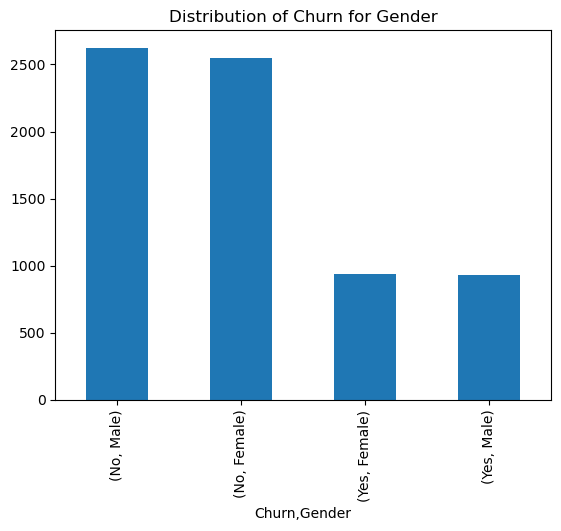

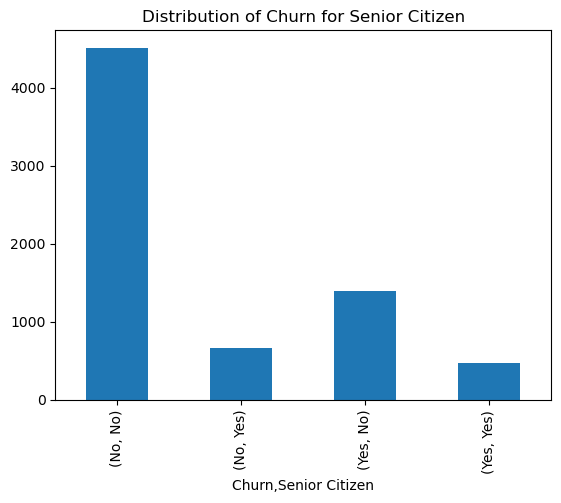

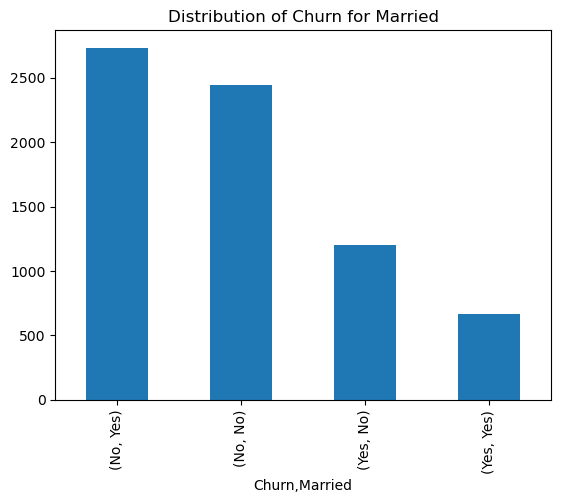

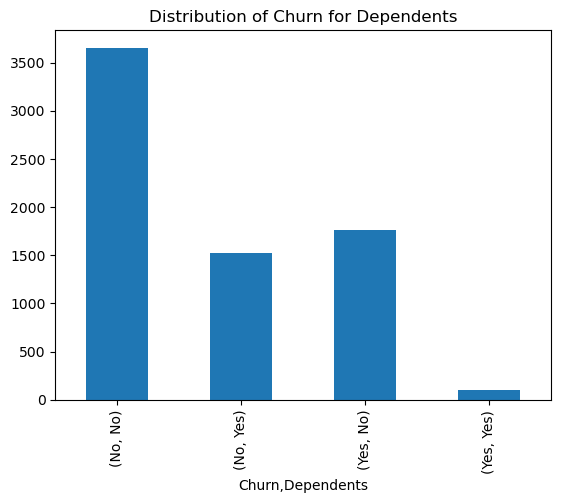

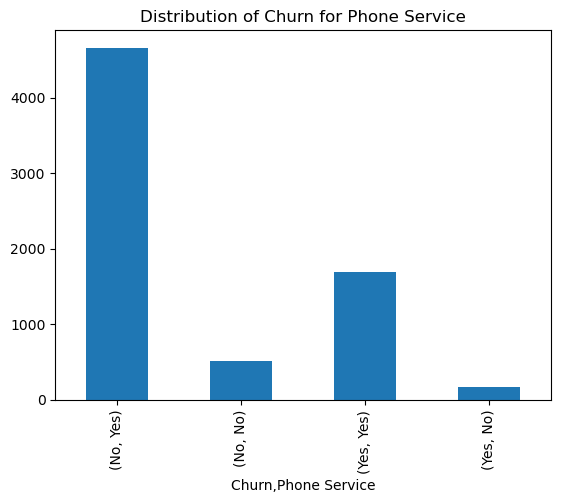

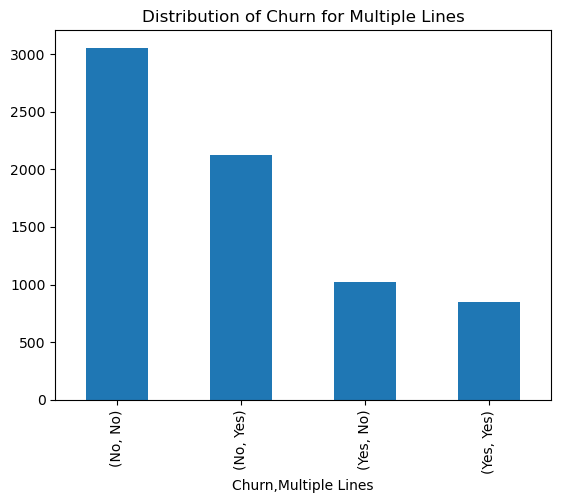

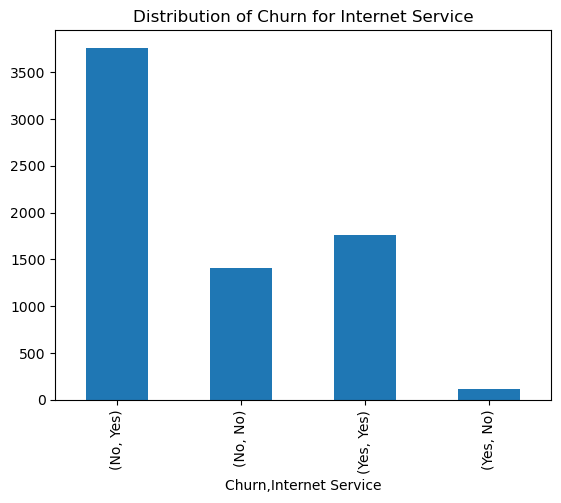

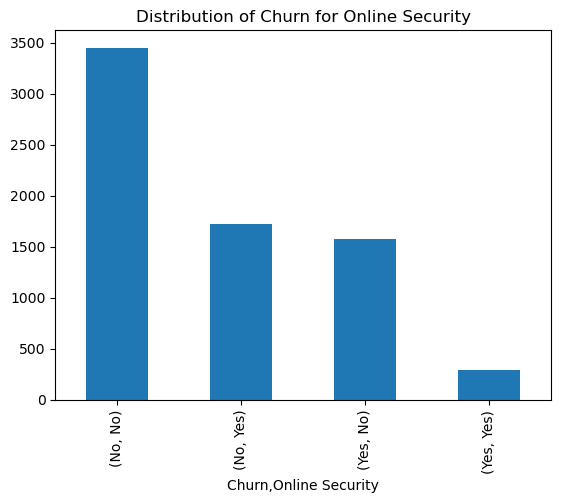

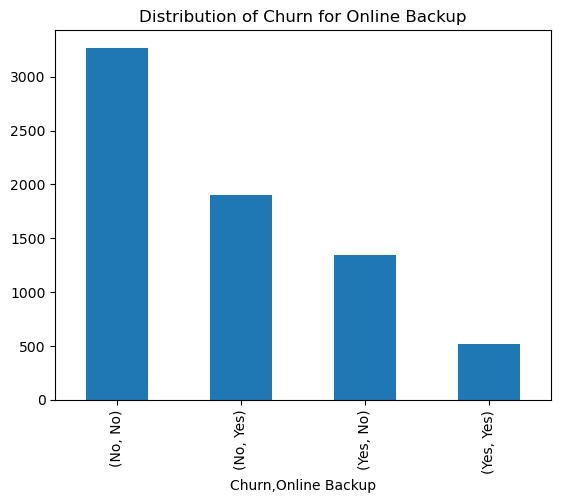

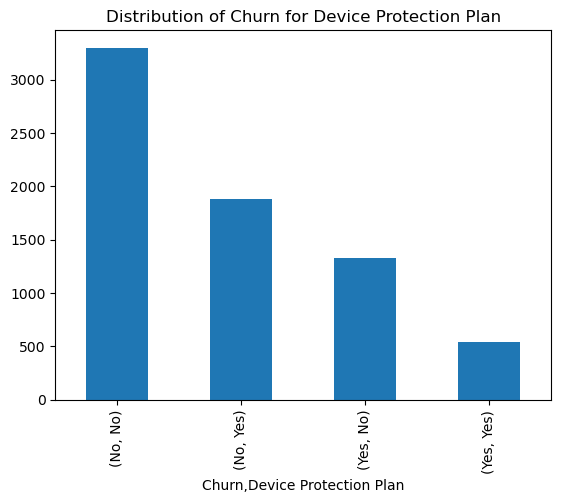

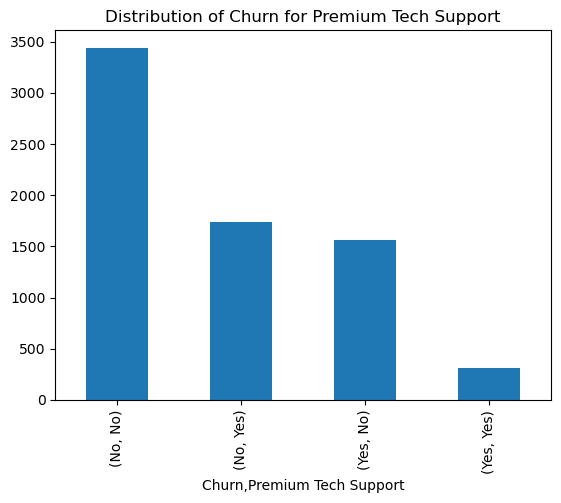

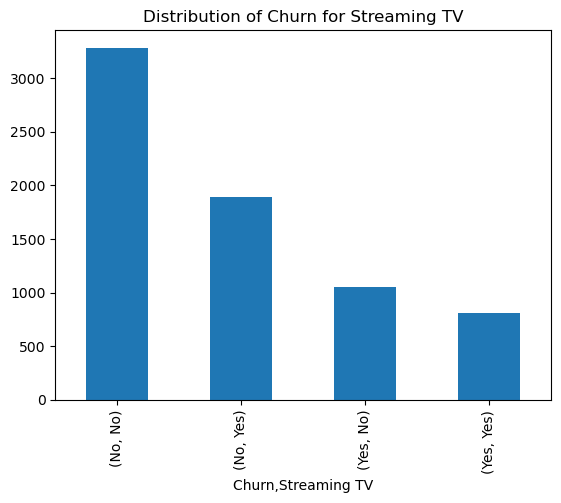

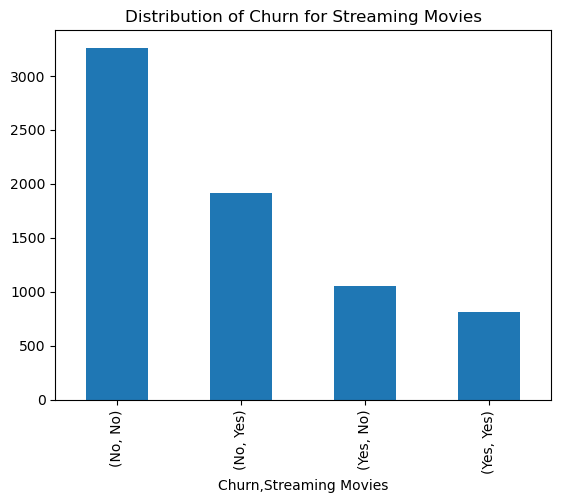

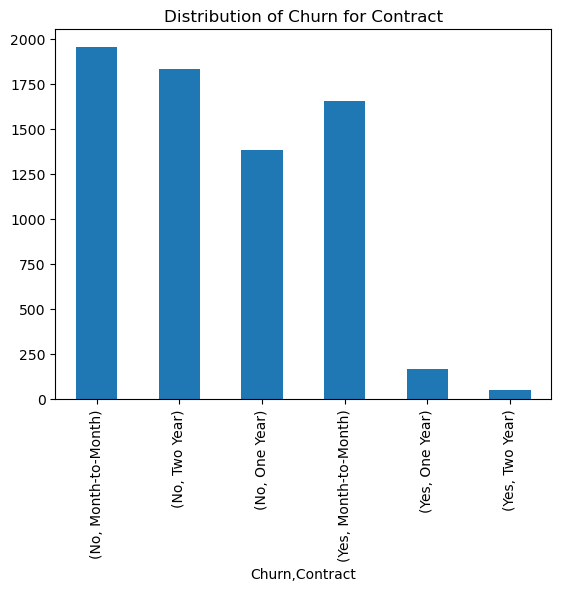

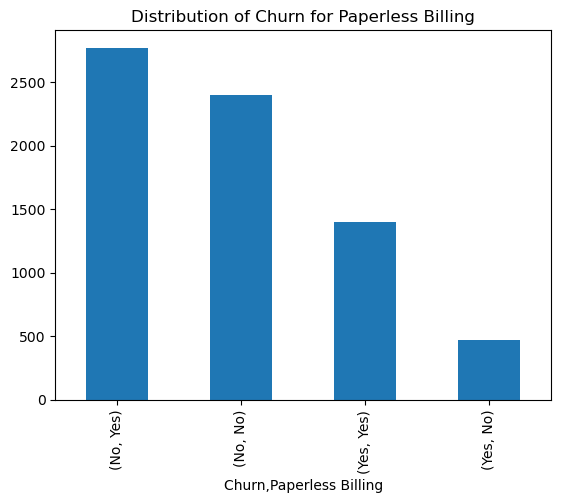

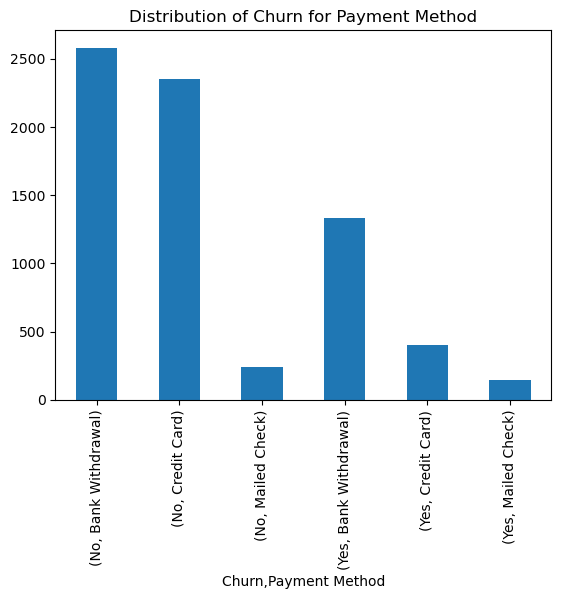

In [11]:
# Plot the churn distribution for the different categorical features
for cols in groupby_churn_df:
    plots = groupby_churn_df[cols].plot(kind='bar', title=f"Distribution of Churn for {cols}")
    plt.show()

##### Note that except for the "Contract" feature, there is no ordering to the categorical columns.

In [12]:
# Prune the data frame by features that have the least impact on churn
# Cut 1: "Unnamed: 0", "Customer ID", "Gender"
# churn_df2 = churn_df.drop(["Unnamed: 0", "Customer ID", "Gender"], axis=1)

# Recall:
churn_df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              7043 non-null   int64  
 1   Customer ID             7043 non-null   object 
 2   Gender                  7043 non-null   object 
 3   Age                     7043 non-null   int64  
 4   Senior Citizen          7043 non-null   object 
 5   Married                 7043 non-null   object 
 6   Dependents              7043 non-null   object 
 7   Tenure in Months        7043 non-null   int64  
 8   Phone Service           7043 non-null   object 
 9   Multiple Lines          7043 non-null   object 
 10  Internet Service        7043 non-null   object 
 11  Online Security         7043 non-null   object 
 12  Online Backup           7043 non-null   object 
 13  Device Protection Plan  7043 non-null   object 
 14  Premium Tech Support    7043 non-null   

### EDA Conclusions

###### 1. There are too many feature variables in the original data set to build a practical, computationally efficient model from. Feature selection will be required.
###### 2. Most of the feature variables, and the target variable itself, are non-numerical, and will require feature engineering.
###### 3. The target variable ("Churn") is unbalanced and so a special metric such as F1 score to evaluate the final predictor model.

### 2. FEATURE ENGINEERING AND SELECTION

#### 2.1 FEATURE ENGINEERING

##### TRAIN-TEST SPLIT

###### Split the data into train and test subsets so that any feature engineering or selection can be performed on the train set, isolating the test set from bias.

In [13]:
# Separate the Churn dataset into train and test subsets
X_churn, y_churn = (churn_df2.drop(["Churn"], axis=1), churn_df2["Churn"])

# Split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X_churn, y_churn, test_size=0.3, random_state=42)

#### 1. Converting Categorical to Numeric Data

###### Since most of the Scikit-learn models require numerical analysis, the categorical data must be represented as numeric data.
###### Recall that only one categorical feature was ordinal.

In [14]:
# Encoding the non-ordinal categorical features using Scikit-learn's OneHotEncoder.
# Instantiate the OneHotEncoder
# one_hot_encoder = OneHotEncoder() # Rejected option because the binary pairs in the categorical data resulted in redundancies, e.g. target correlations that were symmetric about point zero.

# Keeping such redundant data is resource inefficient. Thus, one-hot-encoding was implemented.
one_hot_encoder = OneHotEncoder(drop='first') 

In [15]:
# Create a copy of the Churn dataset to store the one hot encoded TRAIN data.
churn_df3a = pd.DataFrame()

# Create a copy of the Churn dataset to store the one hot encoded TEST data.
churn_df3b = pd.DataFrame()

#### Categorical Feature: Gender

In [16]:
# TRAIN DATA
# Fit the OneHotEncoder to the Gender column and transform.
# first convert the column into a DataFrame
gender_df1 = pd.DataFrame(X_train["Gender"])
gender_encoded_array1 = one_hot_encoder.fit_transform(gender_df1)

# Convert from sparse matrix to dense
gender_dense_array1 = gender_encoded_array1.toarray()

# Put into a dataframe to get column names
#gender_encoded_df1 = pd.DataFrame(gender_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
gender_encoded_df1 = pd.DataFrame(gender_dense_array1, columns=["Gender MALE"], dtype=int) # Due to drop="first" stipulation of OneHotEncoder


# Add to new TRAIN data frame churn_df3a
#X_train[["Gender FEMALE", "Gender MALE"]] = gender_encoded_df1
churn_df3a[["Gender MALE"]] = gender_encoded_df1 # Due to drop="first" stipulation of OneHotEncoder
churn_df3a.head()

,Gender MALE
0,1
1,1
2,1
3,0
4,0


In [17]:
# TEST DATA
# Fit the OneHotEncoder to the Gender column and transform.
# first convert the column into a DataFrame
gender_df2 = pd.DataFrame(X_test["Gender"])
gender_encoded_array2 = one_hot_encoder.fit_transform(gender_df2)

# Convert from sparse matrix to dense
gender_dense_array2 = gender_encoded_array2.toarray()

# Put into a dataframe to get column names
#gender_encoded_df2 = pd.DataFrame(gender_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
gender_encoded_df2 = pd.DataFrame(gender_dense_array2, columns=["Gender MALE"], dtype=int) # Due to drop="first" stipulation of OneHotEncoder


# Add to new TEST data frame churn_df3b
#X_train[["Gender FEMALE", "Gender MALE"]] = gender_encoded_df2
churn_df3b[["Gender MALE"]] = gender_encoded_df2 # Due to drop="first" stipulation of OneHotEncoder
churn_df3b.head()

,Gender MALE
0,0
1,1
2,1
3,0
4,1


#### Categorical Feature: Senior Citizen

In [18]:
# TRAIN DATA
# Fit the OneHotEncoder to the Senior Citizen column and transform.
# first convert the column into a DataFrame
srcitizen_df1 = pd.DataFrame(X_train["Senior Citizen"])
srcitizen_encoded_array1 = one_hot_encoder.fit_transform(srcitizen_df1)

# Convert from sparse matrix to dense
srcitizen_dense_array1 = srcitizen_encoded_array1.toarray()

# Put into a dataframe to get column names
#srcitizen_encoded_df1 = pd.DataFrame(srcitizen_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
srcitizen_encoded_df1 = pd.DataFrame(srcitizen_dense_array1, columns=["SrCitizen YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3[["SrCitizen NO", "SrCitizen YES"]] = srcitizen_encoded_df1
churn_df3a[["SrCitizen YES"]] = srcitizen_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES
0,1,0
1,1,1
2,1,0
3,0,0
4,0,0


In [19]:
# TEST DATA
# Fit the OneHotEncoder to the Senior Citizen column and transform.
# first convert the column into a DataFrame
srcitizen_df2 = pd.DataFrame(X_test["Senior Citizen"])
srcitizen_encoded_array2 = one_hot_encoder.fit_transform(srcitizen_df2)

# Convert from sparse matrix to dense
srcitizen_dense_array2 = srcitizen_encoded_array2.toarray()

# Put into a dataframe to get column names
#srcitizen_encoded_df2 = pd.DataFrame(srcitizen_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
srcitizen_encoded_df2 = pd.DataFrame(srcitizen_dense_array2, columns=["SrCitizen YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3[["SrCitizen NO", "SrCitizen YES"]] = srcitizen_encoded_df2
churn_df3b[["SrCitizen YES"]] = srcitizen_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES
0,0,1
1,1,0
2,1,0
3,0,0
4,1,1


#### Categorical Feature: Married

In [20]:
# TRAIN DATA
# Fit the OneHotEncoder to the Married column and transform.
# first convert the column into a DataFrame
married_df1 = pd.DataFrame(X_train["Married"])
married_encoded_array1 = one_hot_encoder.fit_transform(married_df1)

# Convert from sparse matrix to dense
married_dense_array1 = married_encoded_array1.toarray()

# Put into a dataframe to get column names
#married_encoded_df1 = pd.DataFrame(married_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
married_encoded_df1 = pd.DataFrame(married_dense_array1, columns=["Married YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Married NO", "Married YES"]] = married_encoded_df1
churn_df3a[["Married YES"]] = married_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES
0,1,0,0
1,1,1,0
2,1,0,1
3,0,0,1
4,0,0,0


In [21]:
# TEST DATA
# Fit the OneHotEncoder to the Married column and transform.
# first convert the column into a DataFrame
married_df2 = pd.DataFrame(X_test["Married"])
married_encoded_array2 = one_hot_encoder.fit_transform(married_df2)

# Convert from sparse matrix to dense
married_dense_array2 = married_encoded_array2.toarray()

# Put into a dataframe to get column names
#married_encoded_df2 = pd.DataFrame(married_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
married_encoded_df2 = pd.DataFrame(married_dense_array2, columns=["Married YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Married NO", "Married YES"]] = married_encoded_df2
churn_df3b[["Married YES"]] = married_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES
0,0,1,1
1,1,0,0
2,1,0,1
3,0,0,1
4,1,1,1


#### Categorical Feature: Dependents

In [22]:
# TRAIN DATA
# Fit the OneHotEncoder to the Dependents column and transform.
# first convert the column into a DataFrame
dependents_df1 = pd.DataFrame(X_train["Dependents"])
dependents_encoded_array1 = one_hot_encoder.fit_transform(dependents_df1)

# Convert from sparse matrix to dense
dependents_dense_array1 = dependents_encoded_array1.toarray()

# Put into a dataframe to get column names
#dependents_encoded_df1 = pd.DataFrame(dependents_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
dependents_encoded_df1 = pd.DataFrame(dependents_dense_array1, columns=["Dependents YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Dependents NO", "Dependents YES"]] = dependents_encoded_df1
churn_df3a[["Dependents YES"]] = dependents_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES
0,1,0,0,0
1,1,1,0,0
2,1,0,1,0
3,0,0,1,0
4,0,0,0,0


In [23]:
# TEST DATA
# Fit the OneHotEncoder to the Dependents column and transform.
# first convert the column into a DataFrame
dependents_df2 = pd.DataFrame(X_test["Dependents"])
dependents_encoded_array2 = one_hot_encoder.fit_transform(dependents_df2)

# Convert from sparse matrix to dense
dependents_dense_array2 = dependents_encoded_array2.toarray()

# Put into a dataframe to get column names
#dependents_encoded_df2 = pd.DataFrame(dependents_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
dependents_encoded_df2 = pd.DataFrame(dependents_dense_array2, columns=["Dependents YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Dependents NO", "Dependents YES"]] = dependents_encoded_df2
churn_df3b[["Dependents YES"]] = dependents_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES
0,0,1,1,0
1,1,0,0,0
2,1,0,1,0
3,0,0,1,1
4,1,1,1,0


#### Categorical Feature: Phone Service

In [24]:
# TRAIN DATA
# Fit the OneHotEncoder to the Phone Service column and transform.
# first convert the column into a DataFrame
phone_df1 = pd.DataFrame(X_train["Phone Service"])
phone_encoded_array1 = one_hot_encoder.fit_transform(phone_df1)

# Convert from sparse matrix to dense
phone_dense_array1 = phone_encoded_array1.toarray()

# Put into a dataframe to get column names
#phone_encoded_df1 = pd.DataFrame(phone_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
phone_encoded_df1 = pd.DataFrame(phone_dense_array1, columns=["Phone Service YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Phone Service NO", "Phone Service YES"]] = phone_encoded_df1
churn_df3a[["Phone Service YES"]] = phone_encoded_df1
churn_df3a

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES
0,1,0,0,0,1
1,1,1,0,0,1
2,1,0,1,0,1
3,0,0,1,0,1
4,0,0,0,0,1
...,...,...,...,...,...
4925,1,0,0,0,1
4926,0,0,0,0,1
4927,1,0,0,1,1
4928,0,0,0,1,1


In [25]:
# TEST DATA
# Fit the OneHotEncoder to the Phone Service column and transform.
# first convert the column into a DataFrame
phone_df2 = pd.DataFrame(X_test["Phone Service"])
phone_encoded_array2 = one_hot_encoder.fit_transform(phone_df2)

# Convert from sparse matrix to dense
phone_dense_array2 = phone_encoded_array2.toarray()

# Put into a dataframe to get column names
#phone_encoded_df2 = pd.DataFrame(phone_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
phone_encoded_df2 = pd.DataFrame(phone_dense_array2, columns=["Phone Service YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Phone Service NO", "Phone Service YES"]] = phone_encoded_df2
churn_df3b[["Phone Service YES"]] = phone_encoded_df2
churn_df3b

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES
0,0,1,1,0,1
1,1,0,0,0,1
2,1,0,1,0,1
3,0,0,1,1,1
4,1,1,1,0,1
...,...,...,...,...,...
2108,0,0,0,0,1
2109,1,0,0,0,1
2110,1,0,0,0,1
2111,1,0,1,0,1


#### Categorical Feature: Multiple Lines

In [26]:
# TRAIN DATA
# Fit the OneHotEncoder to the Multiple Lines column and transform.
# first convert the column into a DataFrame
multilines_df1 = pd.DataFrame(X_train["Multiple Lines"])
multilines_encoded_array1 = one_hot_encoder.fit_transform(multilines_df1)

# Convert from sparse matrix to dense
multilines_dense_array1 = multilines_encoded_array1.toarray()

# Put into a dataframe to get column names
#multilines_encoded_df1 = pd.DataFrame(multilines_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
multilines_encoded_df1 = pd.DataFrame(multilines_dense_array1, columns=["Multiple Lines YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Multiple Lines NO", "Multiple Lines YES"]] = multilines_encoded_df1
churn_df3a[["Multiple Lines YES"]] = multilines_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES
0,1,0,0,0,1,1
1,1,1,0,0,1,1
2,1,0,1,0,1,0
3,0,0,1,0,1,0
4,0,0,0,0,1,0


In [27]:
# TEST DATA
# Fit the OneHotEncoder to the Multiple Lines column and transform.
# first convert the column into a DataFrame
multilines_df2 = pd.DataFrame(X_test["Multiple Lines"])
multilines_encoded_array2 = one_hot_encoder.fit_transform(multilines_df2)

# Convert from sparse matrix to dense
multilines_dense_array2 = multilines_encoded_array2.toarray()

# Put into a dataframe to get column names
#multilines_encoded_df2 = pd.DataFrame(multilines_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
multilines_encoded_df2 = pd.DataFrame(multilines_dense_array2, columns=["Multiple Lines YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Multiple Lines NO", "Multiple Lines YES"]] = multilines_encoded_df2
churn_df3b[["Multiple Lines YES"]] = multilines_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES
0,0,1,1,0,1,0
1,1,0,0,0,1,1
2,1,0,1,0,1,0
3,0,0,1,1,1,0
4,1,1,1,0,1,1


#### Categorical Feature: Internet Service

In [28]:
# TRAIN DATA
# Fit the OneHotEncoder to the Internet Service column and transform.
# first convert the column into a DataFrame
internet_df1 = pd.DataFrame(X_train["Internet Service"])
internet_encoded_array1 = one_hot_encoder.fit_transform(internet_df1)

# Convert from sparse matrix to dense
internet_dense_array1 = internet_encoded_array1.toarray()

# Put into a dataframe to get column names
#internet_encoded_df1 = pd.DataFrame(internet_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
internet_encoded_df1 = pd.DataFrame(internet_dense_array1, columns=["Internet Service YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Internet Service NO", "Internet Service YES"]] = internet_encoded_df1
churn_df3a[["Internet Service YES"]] = internet_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES
0,1,0,0,0,1,1,1
1,1,1,0,0,1,1,1
2,1,0,1,0,1,0,0
3,0,0,1,0,1,0,0
4,0,0,0,0,1,0,1


In [29]:
# TEST DATA
# Fit the OneHotEncoder to the Internet Service column and transform.
# first convert the column into a DataFrame
internet_df2 = pd.DataFrame(X_test["Internet Service"])
internet_encoded_array2 = one_hot_encoder.fit_transform(internet_df2)

# Convert from sparse matrix to dense
internet_dense_array2 = internet_encoded_array2.toarray()

# Put into a dataframe to get column names
#internet_encoded_df2 = pd.DataFrame(internet_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
internet_encoded_df2 = pd.DataFrame(internet_dense_array2, columns=["Internet Service YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Internet Service NO", "Internet Service YES"]] = internet_encoded_df2
churn_df3b[["Internet Service YES"]] = internet_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES
0,0,1,1,0,1,0,1
1,1,0,0,0,1,1,0
2,1,0,1,0,1,0,1
3,0,0,1,1,1,0,0
4,1,1,1,0,1,1,1


#### Categorical Feature: Online Security

In [30]:
# TRAIN DATA
# Fit the OneHotEncoder to the Online Security column and transform.
# first convert the column into a DataFrame
security_df1 = pd.DataFrame(X_train["Online Security"])
security_encoded_array1 = one_hot_encoder.fit_transform(security_df1)

# Convert from sparse matrix to dense
security_dense_array1 = security_encoded_array1.toarray()

# Put into a dataframe to get column names
#security_encoded_df1 = pd.DataFrame(security_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
security_encoded_df1 = pd.DataFrame(security_dense_array1, columns=["Online Security YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Online Security NO", "Online Security YES"]] = security_encoded_df1
churn_df3a[["Online Security YES"]] = security_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES
0,1,0,0,0,1,1,1,0
1,1,1,0,0,1,1,1,1
2,1,0,1,0,1,0,0,0
3,0,0,1,0,1,0,0,0
4,0,0,0,0,1,0,1,0


In [31]:
# TEST DATA
# Fit the OneHotEncoder to the Online Security column and transform.
# first convert the column into a DataFrame
security_df2 = pd.DataFrame(X_test["Online Security"])
security_encoded_array2 = one_hot_encoder.fit_transform(security_df2)

# Convert from sparse matrix to dense
security_dense_array2 = security_encoded_array2.toarray()

# Put into a dataframe to get column names
#security_encoded_df2 = pd.DataFrame(security_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
security_encoded_df2 = pd.DataFrame(security_dense_array2, columns=["Online Security YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Online Security NO", "Online Security YES"]] = security_encoded_df2
churn_df3b[["Online Security YES"]] = security_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES
0,0,1,1,0,1,0,1,0
1,1,0,0,0,1,1,0,0
2,1,0,1,0,1,0,1,1
3,0,0,1,1,1,0,0,0
4,1,1,1,0,1,1,1,0


#### Categorical Feature: Online Backup

In [32]:
# TRAIN DATA
# Fit the OneHotEncoder to the Online Backup column and transform.
# first convert the column into a DataFrame
backup_df1 = pd.DataFrame(X_train["Online Backup"])
backup_encoded_array1 = one_hot_encoder.fit_transform(backup_df1)

# Convert from sparse matrix to dense
backup_dense_array1 = backup_encoded_array1.toarray()

# Put into a dataframe to get column names
#backup_encoded_df1 = pd.DataFrame(backup_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
backup_encoded_df1 = pd.DataFrame(backup_dense_array1, columns=["Online Backup YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Online Backup NO", "Online Backup YES"]] = backup_encoded_df1
churn_df3a[["Online Backup YES"]] = backup_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES
0,1,0,0,0,1,1,1,0,0
1,1,1,0,0,1,1,1,1,1
2,1,0,1,0,1,0,0,0,0
3,0,0,1,0,1,0,0,0,0
4,0,0,0,0,1,0,1,0,0


In [33]:
# TEST DATA
# Fit the OneHotEncoder to the Online Backup column and transform.
# first convert the column into a DataFrame
backup_df2 = pd.DataFrame(X_test["Online Backup"])
backup_encoded_array2 = one_hot_encoder.fit_transform(backup_df2)

# Convert from sparse matrix to dense
backup_dense_array2 = backup_encoded_array2.toarray()

# Put into a dataframe to get column names
#backup_encoded_df2 = pd.DataFrame(backup_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
backup_encoded_df2 = pd.DataFrame(backup_dense_array2, columns=["Online Backup YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Online Backup NO", "Online Backup YES"]] = backup_encoded_df2
churn_df3b[["Online Backup YES"]] = backup_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES
0,0,1,1,0,1,0,1,0,0
1,1,0,0,0,1,1,0,0,0
2,1,0,1,0,1,0,1,1,1
3,0,0,1,1,1,0,0,0,0
4,1,1,1,0,1,1,1,0,0


#### Categorical Feature: Device Protection Plan

In [34]:
# TRAIN DATA
# Fit the OneHotEncoder to the Device Protection Plan column and transform.
# first convert the column into a DataFrame
dpp_df1 = pd.DataFrame(X_train["Device Protection Plan"])
dpp_encoded_array1 = one_hot_encoder.fit_transform(dpp_df1)

# Convert from sparse matrix to dense
dpp_dense_array1 = dpp_encoded_array1.toarray()

# Put into a dataframe to get column names
#dpp_encoded_df1 = pd.DataFrame(dpp_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
dpp_encoded_df1 = pd.DataFrame(dpp_dense_array1, columns=["Device Protection Plan YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Device Protection Plan NO", "Device Protection Play YES"]] = dpp_encoded_df1
churn_df3a[["Device Protection Plan YES"]] = dpp_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES
0,1,0,0,0,1,1,1,0,0,1
1,1,1,0,0,1,1,1,1,1,0
2,1,0,1,0,1,0,0,0,0,0
3,0,0,1,0,1,0,0,0,0,0
4,0,0,0,0,1,0,1,0,0,1


In [35]:
# TEST DATA
# Fit the OneHotEncoder to the Device Protection Plan column and transform.
# first convert the column into a DataFrame
dpp_df2 = pd.DataFrame(X_test["Device Protection Plan"])
dpp_encoded_array2 = one_hot_encoder.fit_transform(dpp_df2)

# Convert from sparse matrix to dense
dpp_dense_array2 = dpp_encoded_array2.toarray()

# Put into a dataframe to get column names
#dpp_encoded_df2 = pd.DataFrame(dpp_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
dpp_encoded_df2 = pd.DataFrame(dpp_dense_array2, columns=["Device Protection Plan YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Device Protection Plan NO", "Device Protection Play YES"]] = dpp_encoded_df2
churn_df3b[["Device Protection Plan YES"]] = dpp_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES
0,0,1,1,0,1,0,1,0,0,0
1,1,0,0,0,1,1,0,0,0,0
2,1,0,1,0,1,0,1,1,1,0
3,0,0,1,1,1,0,0,0,0,0
4,1,1,1,0,1,1,1,0,0,0


#### Categorical Feature: Premium Tech Support

In [36]:
# TRAIN DATA
# Fit the OneHotEncoder to the Premium Tech Support column and transform.
# first convert the column into a DataFrame
support_df1 = pd.DataFrame(X_train["Premium Tech Support"])
support_encoded_array1 = one_hot_encoder.fit_transform(support_df1)

# Convert from sparse matrix to dense
support_dense_array1 = support_encoded_array1.toarray()

# Put into a dataframe to get column names
#support_encoded_df1 = pd.DataFrame(support_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
support_encoded_df1 = pd.DataFrame(support_dense_array1, columns=["Premium Tech Support YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Premium Tech Support NO", "Premium Tech Support YES"]] = support_encoded_df1
churn_df3a[["Premium Tech Support YES"]] = support_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES
0,1,0,0,0,1,1,1,0,0,1,0
1,1,1,0,0,1,1,1,1,1,0,0
2,1,0,1,0,1,0,0,0,0,0,0
3,0,0,1,0,1,0,0,0,0,0,0
4,0,0,0,0,1,0,1,0,0,1,1


In [37]:
# TEST DATA
# Fit the OneHotEncoder to the Premium Tech Support column and transform.
# first convert the column into a DataFrame
support_df2 = pd.DataFrame(X_test["Premium Tech Support"])
support_encoded_array2 = one_hot_encoder.fit_transform(support_df2)

# Convert from sparse matrix to dense
support_dense_array2 = support_encoded_array2.toarray()

# Put into a dataframe to get column names
#support_encoded_df2 = pd.DataFrame(support_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
support_encoded_df2 = pd.DataFrame(support_dense_array2, columns=["Premium Tech Support YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Premium Tech Support NO", "Premium Tech Support YES"]] = support_encoded_df2
churn_df3b[["Premium Tech Support YES"]] = support_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES
0,0,1,1,0,1,0,1,0,0,0,0
1,1,0,0,0,1,1,0,0,0,0,0
2,1,0,1,0,1,0,1,1,1,0,0
3,0,0,1,1,1,0,0,0,0,0,0
4,1,1,1,0,1,1,1,0,0,0,0


#### Categorical Feature: Streaming TV

In [38]:
# TRAIN DATA
# Fit the OneHotEncoder to the Streaming TV column and transform.
# first convert the column into a DataFrame
streamtv_df1 = pd.DataFrame(X_train["Streaming TV"])
streamtv_encoded_array1 = one_hot_encoder.fit_transform(streamtv_df1)

# Convert from sparse matrix to dense
streamtv_dense_array1 = streamtv_encoded_array1.toarray()

# Put into a dataframe to get column names
#streamtv_encoded_df1 = pd.DataFrame(streamtv_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
streamtv_encoded_df1 = pd.DataFrame(streamtv_dense_array1, columns=["Streaming TV YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Streaming TV NO", "Streaming TV YES"]] = streamtv_encoded_df1
churn_df3a[["Streaming TV YES"]] = streamtv_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES
0,1,0,0,0,1,1,1,0,0,1,0,1
1,1,1,0,0,1,1,1,1,1,0,0,1
2,1,0,1,0,1,0,0,0,0,0,0,0
3,0,0,1,0,1,0,0,0,0,0,0,0
4,0,0,0,0,1,0,1,0,0,1,1,0


In [39]:
# TEST DATA
# Fit the OneHotEncoder to the Streaming TV column and transform.
# first convert the column into a DataFrame
streamtv_df2 = pd.DataFrame(X_test["Streaming TV"])
streamtv_encoded_array2 = one_hot_encoder.fit_transform(streamtv_df2)

# Convert from sparse matrix to dense
streamtv_dense_array2 = streamtv_encoded_array2.toarray()

# Put into a dataframe to get column names
#streamtv_encoded_df2 = pd.DataFrame(streamtv_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
streamtv_encoded_df2 = pd.DataFrame(streamtv_dense_array2, columns=["Streaming TV YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Streaming TV NO", "Streaming TV YES"]] = streamtv_encoded_df2
churn_df3b[["Streaming TV YES"]] = streamtv_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES
0,0,1,1,0,1,0,1,0,0,0,0,0
1,1,0,0,0,1,1,0,0,0,0,0,0
2,1,0,1,0,1,0,1,1,1,0,0,1
3,0,0,1,1,1,0,0,0,0,0,0,0
4,1,1,1,0,1,1,1,0,0,0,0,1


#### Categorical Feature: Streaming Movies

In [40]:
# TRAIN DATA
# Fit the OneHotEncoder to the Streaming Movies column and transform.
# first convert the column into a DataFrame
streammov_df1 = pd.DataFrame(X_train["Streaming Movies"])
streammov_encoded_array1 = one_hot_encoder.fit_transform(streammov_df1)

# Convert from sparse matrix to dense
streammov_dense_array1 = streammov_encoded_array1.toarray()

# Put into a dataframe to get column names
#streammov_encoded_df1 = pd.DataFrame(streammov_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
streammov_encoded_df1 = pd.DataFrame(streammov_dense_array1, columns=["Streaming Movies YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Streaming Movies NO", "Streaming Movies YES"]] = streammov_encoded_df1
churn_df3a[["Streaming Movies YES"]] = streammov_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES,Streaming Movies YES
0,1,0,0,0,1,1,1,0,0,1,0,1,1
1,1,1,0,0,1,1,1,1,1,0,0,1,0
2,1,0,1,0,1,0,0,0,0,0,0,0,0
3,0,0,1,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,1,0,0,1,1,0,1


In [41]:
# TEST DATA
# Fit the OneHotEncoder to the Streaming Movies column and transform.
# first convert the column into a DataFrame
streammov_df2 = pd.DataFrame(X_test["Streaming Movies"])
streammov_encoded_array2 = one_hot_encoder.fit_transform(streammov_df2)

# Convert from sparse matrix to dense
streammov_dense_array2 = streammov_encoded_array2.toarray()

# Put into a dataframe to get column names
#streammov_encoded_df2 = pd.DataFrame(streammov_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
streammov_encoded_df2 = pd.DataFrame(streammov_dense_array2, columns=["Streaming Movies YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Streaming Movies NO", "Streaming Movies YES"]] = streammov_encoded_df2
churn_df3b[["Streaming Movies YES"]] = streammov_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES,Streaming Movies YES
0,0,1,1,0,1,0,1,0,0,0,0,0,0
1,1,0,0,0,1,1,0,0,0,0,0,0,0
2,1,0,1,0,1,0,1,1,1,0,0,1,1
3,0,0,1,1,1,0,0,0,0,0,0,0,0
4,1,1,1,0,1,1,1,0,0,0,0,1,1


#### Categorical Feature: Paperless Billing

In [42]:
# TRAIN DATA
# Fit the OneHotEncoder to the Paperless Billing column and transform.
# first convert the column into a DataFrame
billing_df1 = pd.DataFrame(X_train["Paperless Billing"])
billing_encoded_array1 = one_hot_encoder.fit_transform(billing_df1)

# Convert from sparse matrix to dense
billing_dense_array1 = billing_encoded_array1.toarray()

# Put into a dataframe to get column names
#billing_encoded_df1 = pd.DataFrame(billing_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
billing_encoded_df1 = pd.DataFrame(billing_dense_array1, columns=["Paperless Billing YES"], dtype=int)

# Add to new TRAIN data frame churn_df3a
#churn_df3a[["Paperless Billing NO", "Paperless Billing YES"]] = billing_encoded_df1
churn_df3a[["Paperless Billing YES"]] = billing_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES,Streaming Movies YES,Paperless Billing YES
0,1,0,0,0,1,1,1,0,0,1,0,1,1,1
1,1,1,0,0,1,1,1,1,1,0,0,1,0,1
2,1,0,1,0,1,0,0,0,0,0,0,0,0,1
3,0,0,1,0,1,0,0,0,0,0,0,0,0,1
4,0,0,0,0,1,0,1,0,0,1,1,0,1,0


In [43]:
# TEST DATA
# Fit the OneHotEncoder to the Paperless Billing column and transform.
# first convert the column into a DataFrame
billing_df2 = pd.DataFrame(X_test["Paperless Billing"])
billing_encoded_array2 = one_hot_encoder.fit_transform(billing_df2)

# Convert from sparse matrix to dense
billing_dense_array2 = billing_encoded_array2.toarray()

# Put into a dataframe to get column names
#billing_encoded_df2 = pd.DataFrame(billing_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
billing_encoded_df2 = pd.DataFrame(billing_dense_array2, columns=["Paperless Billing YES"], dtype=int)

# Add to new TEST data frame churn_df3b
#churn_df3b[["Paperless Billing NO", "Paperless Billing YES"]] = billing_encoded_df2
churn_df3b[["Paperless Billing YES"]] = billing_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES,Streaming Movies YES,Paperless Billing YES
0,0,1,1,0,1,0,1,0,0,0,0,0,0,0
1,1,0,0,0,1,1,0,0,0,0,0,0,0,0
2,1,0,1,0,1,0,1,1,1,0,0,1,1,1
3,0,0,1,1,1,0,0,0,0,0,0,0,0,1
4,1,1,1,0,1,1,1,0,0,0,0,1,1,1


#### Categorical Feature: Payment Method

In [44]:
# TRAIN DATA
# Fit the OneHotEncoder to the Payment Method column and transform.
# Instantiate the OneHotEncoder WITHOUT drop-first
one_hot_encoder = OneHotEncoder()

# Convert the column into a DataFrame
paymethod_df1 = pd.DataFrame(X_train["Payment Method"])

# Fit the OneHotEncoder
paymethod_encoded_array1 = one_hot_encoder.fit_transform(paymethod_df1)

# Convert from sparse matrix to dense
paymethod_dense_array1 = paymethod_encoded_array1.toarray()

# Put into a dataframe to get column names
paymethod_encoded_df1 = pd.DataFrame(paymethod_dense_array1, columns=one_hot_encoder.categories_, dtype=int)
#paymethod_encoded_df1 = pd.DataFrame(paymethod_dense_array1, columns=["Pay Method CREDIT CARD", "Pay Method MAILED CHK"], dtype=int)

# Add to new TRAIN data frame churn_df3a
churn_df3a[["Pay Method BANK WITHDRAWAL", "Pay Method CREDIT CARD", "Pay Method MAILED CHK"]] = paymethod_encoded_df1
#churn_df3a[["Pay Method CREDIT CARD", "Pay Method MAILED CHK"]] = paymethod_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES,Streaming Movies YES,Paperless Billing YES,Pay Method BANK WITHDRAWAL,Pay Method CREDIT CARD,Pay Method MAILED CHK
0,1,0,0,0,1,1,1,0,0,1,0,1,1,1,1,0,0
1,1,1,0,0,1,1,1,1,1,0,0,1,0,1,1,0,0
2,1,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0
3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0
4,0,0,0,0,1,0,1,0,0,1,1,0,1,0,0,1,0


In [45]:
# TEST DATA
# Fit the OneHotEncoder to the Payment Method column and transform.
# Instantiate the OneHotEncoder WITHOUT drop-first
one_hot_encoder = OneHotEncoder()

# Convert the column into a DataFrame
paymethod_df2 = pd.DataFrame(X_test["Payment Method"])

# Fit the OneHotEncoder
paymethod_encoded_array2 = one_hot_encoder.fit_transform(paymethod_df2)

# Convert from sparse matrix to dense
paymethod_dense_array2 = paymethod_encoded_array2.toarray()

# Put into a dataframe to get column names
paymethod_encoded_df2 = pd.DataFrame(paymethod_dense_array2, columns=one_hot_encoder.categories_, dtype=int)
#paymethod_encoded_df2 = pd.DataFrame(paymethod_dense_array2, columns=["Pay Method CREDIT CARD", "Pay Method MAILED CHK"], dtype=int)

# Add to new TEST data frame churn_df3b
churn_df3b[["Pay Method BANK WITHDRAWAL", "Pay Method CREDIT CARD", "Pay Method MAILED CHK"]] = paymethod_encoded_df2
#churn_df3b[["Pay Method CREDIT CARD", "Pay Method MAILED CHK"]] = paymethod_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES,Streaming Movies YES,Paperless Billing YES,Pay Method BANK WITHDRAWAL,Pay Method CREDIT CARD,Pay Method MAILED CHK
0,0,1,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0
2,1,0,1,0,1,0,1,1,1,0,0,1,1,1,0,1,0
3,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,1,0
4,1,1,1,0,1,1,1,0,0,0,0,1,1,1,1,0,0


#### Categorical Feature: Contract

#### Encoding the ordinal categorical feature using Scikit-learn's OrdinalEncoder.

In [46]:
# TRAIN DATA
# Instantiating and encoding the ordinal cardinal feature ("Contract").
contract_ordinal_encoder1 = OrdinalEncoder(categories=[["Month-to-Month", "One Year", "Two Year"]])

#ordinal_encoder.categories_
contract_df1 = pd.DataFrame(X_train["Contract"])
contract_ordinal_encoded_array1 = contract_ordinal_encoder1.fit_transform(contract_df1)

# Put into a dataframe to get column names
contract_ordinal_encoded_df1 = pd.DataFrame(contract_ordinal_encoded_array1, columns=["Contract"], dtype=int)

# Add to new TRAIN data frame churn_df3a
churn_df3a[["Contract"]] = contract_ordinal_encoded_df1
churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES,Streaming Movies YES,Paperless Billing YES,Pay Method BANK WITHDRAWAL,Pay Method CREDIT CARD,Pay Method MAILED CHK,Contract
0,1,0,0,0,1,1,1,0,0,1,0,1,1,1,1,0,0,0
1,1,1,0,0,1,1,1,1,1,0,0,1,0,1,1,0,0,0
2,1,0,1,0,1,0,0,0,0,0,0,0,0,1,1,0,0,1
3,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,1,0,1
4,0,0,0,0,1,0,1,0,0,1,1,0,1,0,0,1,0,1


In [47]:
# TEST DATA
# Instantiating and encoding the ordinal cardinal feature ("Contract").
contract_ordinal_encoder2 = OrdinalEncoder(categories=[["Month-to-Month", "One Year", "Two Year"]])

#ordinal_encoder.categories_
contract_df2 = pd.DataFrame(X_test["Contract"])
contract_ordinal_encoded_array2 = contract_ordinal_encoder1.fit_transform(contract_df2)

# Put into a dataframe to get column names
contract_ordinal_encoded_df2 = pd.DataFrame(contract_ordinal_encoded_array2, columns=["Contract"], dtype=int)

# Add to new TEST data frame churn_df3b
churn_df3b[["Contract"]] = contract_ordinal_encoded_df2
churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,Premium Tech Support YES,Streaming TV YES,Streaming Movies YES,Paperless Billing YES,Pay Method BANK WITHDRAWAL,Pay Method CREDIT CARD,Pay Method MAILED CHK,Contract
0,0,1,1,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0
1,1,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,2
2,1,0,1,0,1,0,1,1,1,0,0,1,1,1,0,1,0,1
3,0,0,1,1,1,0,0,0,0,0,0,0,0,1,0,1,0,0
4,1,1,1,0,1,1,1,0,0,0,0,1,1,1,1,0,0,0


##### 2. Numerical Feature Engineering

In [48]:
# Prepare a dataframe with the numerical features plus 'Churn'
churn_num_df = churn_df2[['Age', 'Tenure in Months', 'Monthly Charge', 'Total Charges', 'Churn']]
churn_num_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               7043 non-null   int64  
 1   Tenure in Months  7043 non-null   int64  
 2   Monthly Charge    7043 non-null   float64
 3   Total Charges     7043 non-null   float64
 4   Churn             7043 non-null   object 
dtypes: float64(2), int64(2), object(1)
memory usage: 275.2+ KB


###### Graphical inspection of numerical feature distribution and scaling

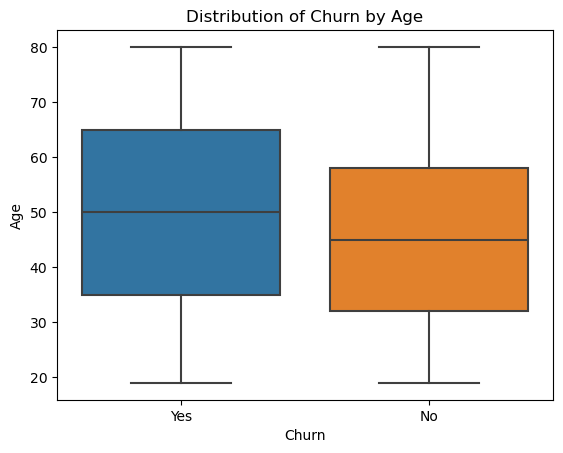

In [49]:
# Plot Age grouped by Churn
plt.figure()

sns.boxplot(data=churn_num_df[['Age', 'Churn']], y="Age", x="Churn")

plt.xlabel("Churn")
plt.ylabel("Age")
plt.title("Distribution of Churn by Age")
plt.show()

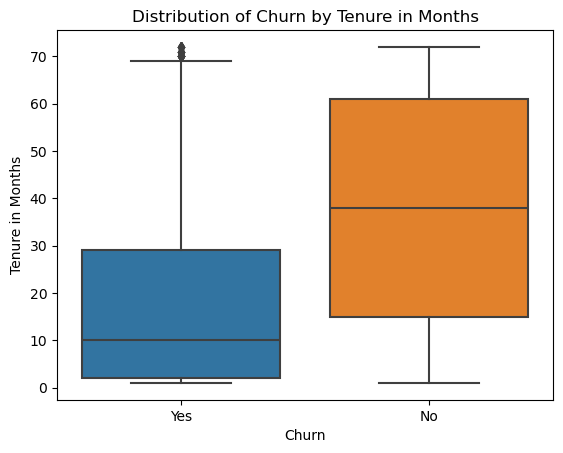

In [50]:
# Plot Tenure in Months grouped by Churn
plt.figure()

sns.boxplot(data=churn_num_df[['Tenure in Months', 'Churn']], y="Tenure in Months", x="Churn")

plt.xlabel("Churn")
plt.ylabel("Tenure in Months")
plt.title("Distribution of Churn by Tenure in Months")
plt.show()

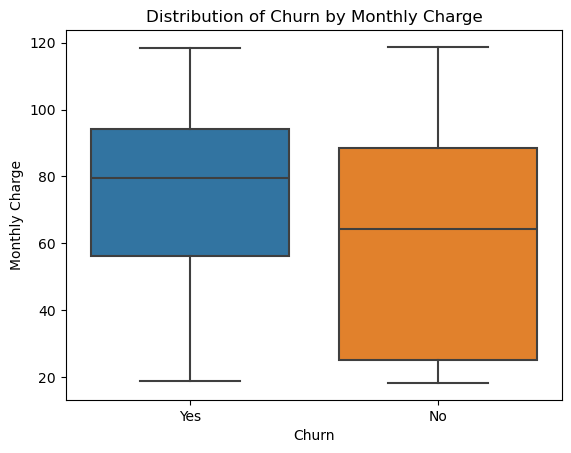

In [51]:
# Plot Monthly Charge grouped by Churn
plt.figure()

sns.boxplot(data=churn_num_df[['Monthly Charge', 'Churn']], y="Monthly Charge", x="Churn")

plt.xlabel("Churn")
plt.ylabel("Monthly Charge")
plt.title("Distribution of Churn by Monthly Charge")
plt.show()

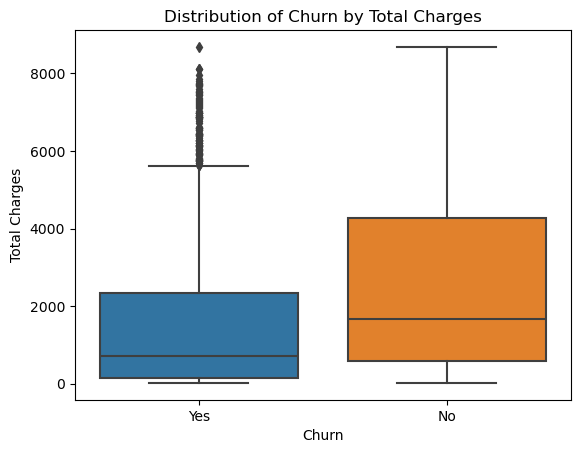

In [52]:
# Plot Total Charges grouped by Churn
plt.figure()

sns.boxplot(data=churn_num_df[['Total Charges', 'Churn']], y="Total Charges", x="Churn")

plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.title("Distribution of Churn by Total Charges")
plt.show()

###### "Age" looks normally distributed. The other features deviate.
###### Except for "Total Charges", the numerical features generally spread over one order of magnitude.
###### Because of the distribution of especially "Total Charges", feature scaling will be implemented.

###### Numerical feature distribution analysis.
###### It is assumed that the feature observations should be normally distributed.

In [53]:
# TRAIN
# Insert the numerical features into the TRAIN dataframe churn_df3a
churn_df3a["Age"] = X_train["Age"]
churn_df3a["Tenure in Months"] = X_train["Tenure in Months"]
churn_df3a["Monthly Charge"] = X_train["Monthly Charge"]
churn_df3a["Total Charges"] = X_train["Total Charges"]

churn_df3a.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,...,Streaming Movies YES,Paperless Billing YES,Pay Method BANK WITHDRAWAL,Pay Method CREDIT CARD,Pay Method MAILED CHK,Contract,Age,Tenure in Months,Monthly Charge,Total Charges
0,1,0,0,0,1,1,1,0,0,1,...,1,1,1,0,0,0,78.0,1.0,39.65,39.65
1,1,1,0,0,1,1,1,1,1,0,...,0,1,1,0,0,0,74.0,8.0,80.65,633.30
2,1,0,1,0,1,0,0,0,0,0,...,0,1,1,0,0,1,71.0,18.0,95.45,1752.55
3,0,0,1,0,1,0,0,0,0,0,...,0,1,0,1,0,1,78.0,25.0,98.50,2514.50
4,0,0,0,0,1,0,1,0,0,1,...,1,0,0,1,0,1,80.0,37.0,76.50,2868.15


In [54]:
# TEST
# Insert the numerical features into the TEST dataframe churn_df3b
churn_df3b["Age"] = X_test["Age"]
churn_df3b["Tenure in Months"] = X_test["Tenure in Months"]
churn_df3b["Monthly Charge"] = X_test["Monthly Charge"]
churn_df3b["Total Charges"] = X_test["Total Charges"]

churn_df3b.head()

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,...,Streaming Movies YES,Paperless Billing YES,Pay Method BANK WITHDRAWAL,Pay Method CREDIT CARD,Pay Method MAILED CHK,Contract,Age,Tenure in Months,Monthly Charge,Total Charges
0,0,1,1,0,1,0,1,0,0,0,...,0,0,1,0,0,0,NaN,NaN,NaN,NaN
1,1,0,0,0,1,1,0,0,0,0,...,0,0,1,0,0,2,NaN,NaN,NaN,NaN
2,1,0,1,0,1,0,1,1,1,0,...,1,1,0,1,0,1,NaN,NaN,NaN,NaN
3,0,0,1,1,1,0,0,0,0,0,...,0,1,0,1,0,0,NaN,NaN,NaN,NaN
4,1,1,1,0,1,1,1,0,0,0,...,1,1,1,0,0,0,NaN,NaN,NaN,NaN


#### Label (target variable) encoding

In [55]:
# TRAIN DATA
# Instantiate the label encoder
label_encoder1 = LabelEncoder()

# Fit and transform the order priority column
churn_df3a["Churn"] = label_encoder1.fit_transform(y_train)
churn_df3a

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,...,Paperless Billing YES,Pay Method BANK WITHDRAWAL,Pay Method CREDIT CARD,Pay Method MAILED CHK,Contract,Age,Tenure in Months,Monthly Charge,Total Charges,Churn
0,1,0,0,0,1,1,1,0,0,1,...,1,1,0,0,0,78.0,1.0,39.65,39.65,1
1,1,1,0,0,1,1,1,1,1,0,...,1,1,0,0,0,74.0,8.0,80.65,633.30,0
2,1,0,1,0,1,0,0,0,0,0,...,1,1,0,0,1,71.0,18.0,95.45,1752.55,0
3,0,0,1,0,1,0,0,0,0,0,...,1,0,1,0,1,78.0,25.0,98.50,2514.50,0
4,0,0,0,0,1,0,1,0,0,1,...,0,0,1,0,1,80.0,37.0,76.50,2868.15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4925,1,0,0,0,1,0,0,0,0,0,...,0,0,0,1,0,42.0,44.0,65.40,2774.55,0
4926,0,0,0,0,1,0,1,0,1,0,...,0,0,1,0,0,32.0,69.0,59.75,4069.90,0
4927,1,0,0,1,1,0,1,0,0,0,...,0,0,1,0,0,NaN,NaN,NaN,NaN,0
4928,0,0,0,1,1,1,1,0,0,0,...,1,0,1,0,1,32.0,57.0,99.65,5497.05,0


In [56]:
# TEST DATA
# Instantiate the label encoder
label_encoder2 = LabelEncoder()

# Fit and transform the order priority column
churn_df3b["Churn"] = label_encoder2.fit_transform(y_test)
churn_df3b

,Gender MALE,SrCitizen YES,Married YES,Dependents YES,Phone Service YES,Multiple Lines YES,Internet Service YES,Online Security YES,Online Backup YES,Device Protection Plan YES,...,Paperless Billing YES,Pay Method BANK WITHDRAWAL,Pay Method CREDIT CARD,Pay Method MAILED CHK,Contract,Age,Tenure in Months,Monthly Charge,Total Charges,Churn
0,0,1,1,0,1,0,1,0,0,0,...,0,1,0,0,0,NaN,NaN,NaN,NaN,1
1,1,0,0,0,1,1,0,0,0,0,...,0,1,0,0,2,NaN,NaN,NaN,NaN,0
2,1,0,1,0,1,0,1,1,1,0,...,1,0,1,0,1,NaN,NaN,NaN,NaN,0
3,0,0,1,1,1,0,0,0,0,0,...,1,0,1,0,0,NaN,NaN,NaN,NaN,1
4,1,1,1,0,1,1,1,0,0,0,...,1,1,0,0,0,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2108,0,0,0,0,1,0,0,0,0,0,...,1,0,1,0,0,NaN,NaN,NaN,NaN,0
2109,1,0,0,0,1,1,1,1,0,1,...,1,1,0,0,2,NaN,NaN,NaN,NaN,0
2110,1,0,0,0,1,1,1,1,0,0,...,0,0,1,0,0,55.0,4.0,50.90,225.6,0
2111,1,0,1,0,1,1,1,1,1,1,...,0,1,0,0,1,NaN,NaN,NaN,NaN,1


#### 2.2 FEATURE SELECTION

#### Feature-Target Correlation Analysis

In [57]:
# Write code to work out the Pearson correlations between each feature and target
churn_df3a.corr()["Churn"].sort_values(ascending=False)

# A previous iteration revealed that features with "YES/NO" responses are symmetric about the zero correlation mark. 
# Only one consistent option (e.g., "YES") need be considered, which would improve model resource efficiency. 

Churn                         1.000000
Internet Service YES          0.225947
Pay Method BANK WITHDRAWAL    0.189115
Paperless Billing YES         0.179743
SrCitizen YES                 0.137661
Streaming Movies YES          0.062004
Streaming TV YES              0.053583
Pay Method MAILED CHK         0.052836
Multiple Lines YES            0.036834
Phone Service YES             0.007217
Gender MALE                  -0.004217
Tenure in Months             -0.008118
Age                          -0.009503
Total Charges                -0.026290
Monthly Charge               -0.050281
Online Backup YES            -0.071921
Device Protection Plan YES   -0.076538
Married YES                  -0.146641
Premium Tech Support YES     -0.148795
Online Security YES          -0.158323
Pay Method CREDIT CARD       -0.217382
Dependents YES               -0.248651
Contract                     -0.430623
Name: Churn, dtype: float64

#### Feature-Feature Correlation Analysis

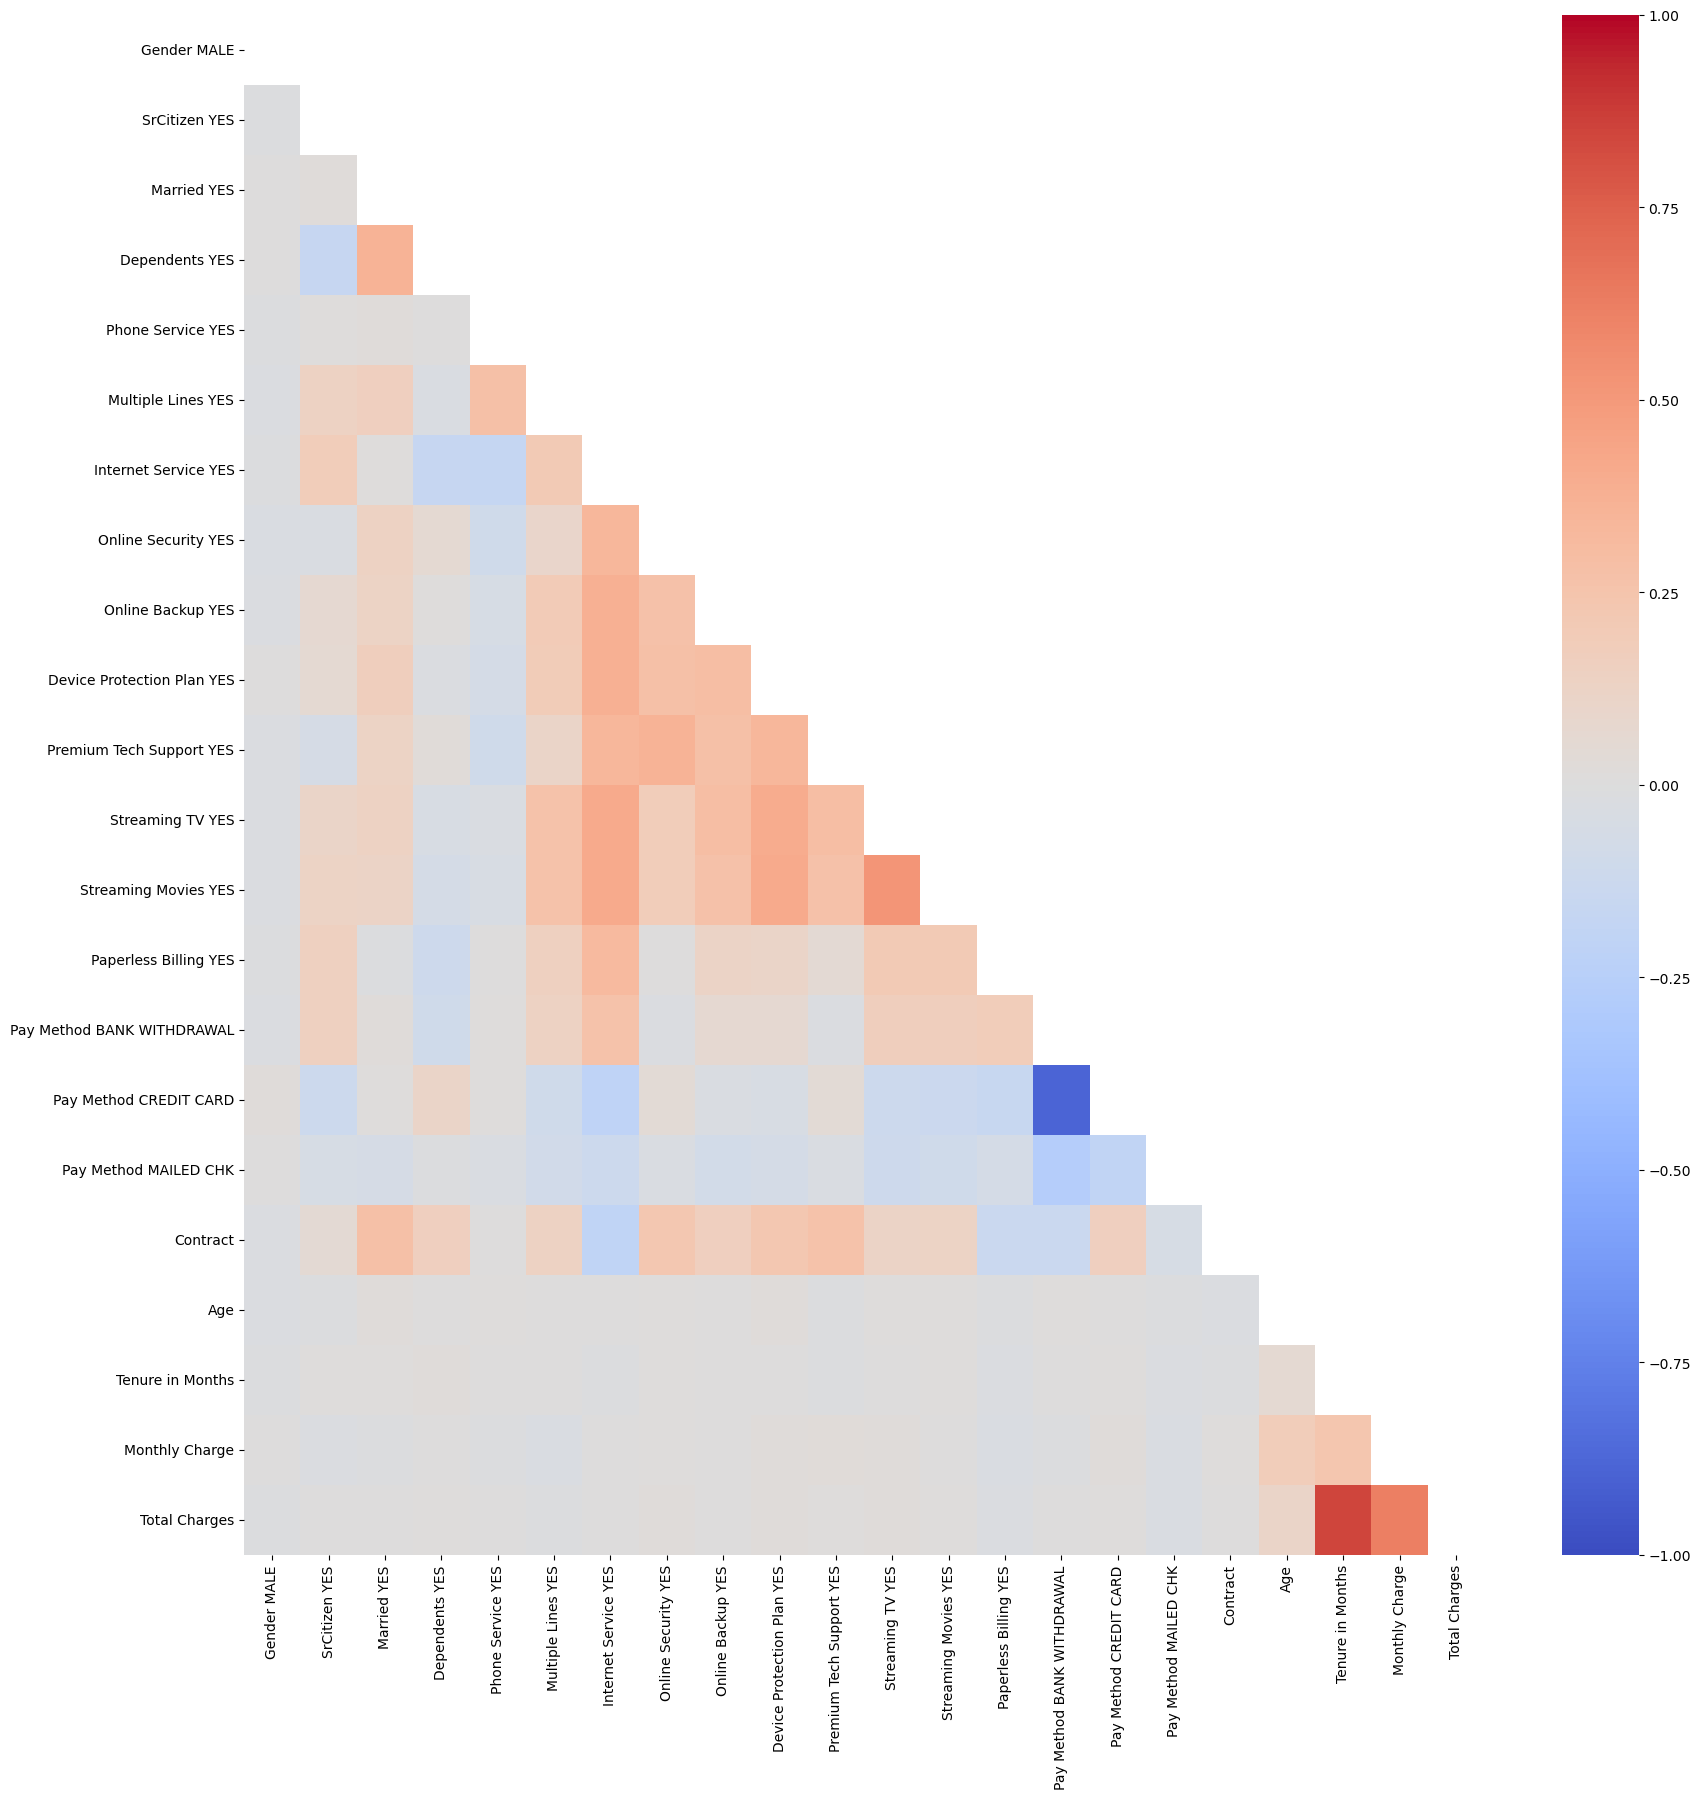

In [58]:
# Isolate the feature variables
churnX_df3a = churn_df3a.drop(['Churn'], axis=1)

# Calculate the cross correlation of the feature variables.
xcorr_df1 = churnX_df3a.corr()

#masking for the upper-triangle
mask = np.triu(xcorr_df1)

plt.figure(figsize=(20,20))
sns.heatmap(xcorr_df1.round(2), annot=True, vmax=1, vmin=-1, center=0, mask=mask, cmap='coolwarm');


###### The strongest positive intercorrelation was between Total Charges and Tenure in Months.
###### Total Charges and Monthly Charges had the next highest positive intercorrelation.
###### Streaming Movies and Streaming TV had a noticeable positive intercorrelation.
###### Having Internet Services had a noticeably positive intercorrelation with several other features.
###### Being married had a weaker, yet still noticieable positive intercorrelation with several other features.
###### Unsurprisingly, paying by bank and paying by credit card had strong negative intercorrelation.
###### Having phone service had a faint but noticeable negative intercorrelation with several other features.
###### Payment via check mailing had a fainty but noticeable negative intercorrelation with several other features.

###### An analysis of variance should reveal which features are more predictive of churn.

###### Unsurprisingly, Age and Senior citizen are highly correlated. Being a senior citizen is a function of age.
###### Age would be the preferred variable to keep as it a measured/numeric quantity, but being a senior citizen correlates more highly with the target variable Churn.

###### Contract and Tenure in Months both track time of service, so their high correlation should be expected. 
###### More interestingly, both are the top two correlating features (by absolute value) with Churn.
###### Contract has the higher absolute value correlation, but it is a categorical feature with four categories, making its interpretation more complicated.
###### A legend would always be necessary to interpret the Contract factor.
###### On the other hand, Tenure in Months is numeric, and therefore straightforward to interpret.

###### That Total Charges and Tenure in Months were highly correlated provides an opportunity for model simplification.
###### The distribution of Total Charges is less ideal than that of Tenure in Months, and Tenure in Months correlates more highly with Churn.
###### Keeping both variables would be redundant, so Total Charges can be confidently dropped, removing the need to transform it to fit the model, which would have created more complexity.

#### Analysis of Variance

###### Numerical data should be scaled before analyzing variance (show how the numerical data cover different scales)

###### Numerical feature scaling analysis (variance)

In [59]:
# Produce the natural variances of the numeric data, and sort from greatest to least. 
X_num1 = X_train[["Age", "Monthly Charge", "Tenure in Months", "Total Charges"]]
X_num1.var().sort_values(ascending=False)

# As suggested by the box plots, the distribution for "Total Charges" is orders of magnitude different from the others.
# The data should be scaled for fair comparison.

Total Charges       5.127603e+06
Monthly Charge      8.971451e+02
Tenure in Months    5.988526e+02
Age                 2.795830e+02
dtype: float64

In [60]:
# Scaling the data
scaler = MinMaxScaler()

X_train_num = X_train[["Age", "Monthly Charge", "Tenure in Months", "Total Charges"]]
scaled_data = scaler.fit_transform(X_num1)
X_num1_scaled = pd.DataFrame(data=scaled_data, columns=X_num1.columns)

# Plot the scaled variances, from greatest to least
X_num1_scaled.var().sort_values(ascending=False)

Tenure in Months    0.118796
Monthly Charge      0.088824
Age                 0.075137
Total Charges       0.068278
dtype: float64

###### Only one of the numerical variables have a variance greater than 0.1

###### Categorical data need not be scaled, but should be converted to proportions in order to measure variance.

In [61]:
churn_prop_df3a = pd.DataFrame()

In [62]:
# Isolate the categorical variables
X_cat1 = churn_df3a.drop(["Age", "Monthly Charge", "Tenure in Months", "Total Charges"], axis=1)

# Generate the proportions
churn_prop_df3a["Gender MALE"] = X_cat1["Gender MALE"].value_counts(normalize=True)
churn_prop_df3a["SrCitizen YES"] = X_cat1["SrCitizen YES"].value_counts(normalize=True)
churn_prop_df3a["Married YES"] = X_cat1["Married YES"].value_counts(normalize=True)
churn_prop_df3a["Dependents YES"] = X_cat1["Dependents YES"].value_counts(normalize=True)
churn_prop_df3a["Phone Service YES"] = X_cat1["Phone Service YES"].value_counts(normalize=True)
churn_prop_df3a["Multiple Lines YES"] = X_cat1["Multiple Lines YES"].value_counts(normalize=True)
churn_prop_df3a["Internet Service YES"] = X_cat1["Internet Service YES"].value_counts(normalize=True)
churn_prop_df3a["Online Security YES"] = X_cat1["Online Security YES"].value_counts(normalize=True)
churn_prop_df3a["Online Backup YES"] = X_cat1["Online Backup YES"].value_counts(normalize=True)
churn_prop_df3a["Device Protection Plan YES"] = X_cat1["Device Protection Plan YES"].value_counts(normalize=True)
churn_prop_df3a["Premium Tech Support YES"] = X_cat1["Premium Tech Support YES"].value_counts(normalize=True)
churn_prop_df3a["Streaming TV YES"] = X_cat1["Streaming TV YES"].value_counts(normalize=True)
churn_prop_df3a["Streaming Movies YES"] = X_cat1["Streaming Movies YES"].value_counts(normalize=True)
churn_prop_df3a["Paperless Billing YES"] = X_cat1["Paperless Billing YES"].value_counts(normalize=True)
churn_prop_df3a["Pay Method BANK WITHDRAWAL"] = X_cat1["Pay Method BANK WITHDRAWAL"].value_counts(normalize=True)
churn_prop_df3a["Pay Method CREDIT CARD"] = X_cat1["Pay Method CREDIT CARD"].value_counts(normalize=True)
churn_prop_df3a["Pay Method MAILED CHK"] = X_cat1["Pay Method MAILED CHK"].value_counts(normalize=True)
churn_prop_df3a["Contract"] = X_cat1["Contract"].value_counts(normalize=True)

# List the variances in decending order
churn_prop_df3a.var().sort_values(ascending=False)

Pay Method MAILED CHK         0.395382
Phone Service YES             0.324233
SrCitizen YES                 0.231973
Internet Service YES          0.163133
Dependents YES                0.144903
Online Security YES           0.084441
Premium Tech Support YES      0.083278
Online Backup YES             0.049936
Device Protection Plan YES    0.048535
Contract                      0.040264
Streaming Movies YES          0.026455
Streaming TV YES              0.025805
Pay Method CREDIT CARD        0.023465
Paperless Billing YES         0.013833
Multiple Lines YES            0.012774
Pay Method BANK WITHDRAWAL    0.005606
Married YES                   0.000681
Gender MALE                   0.000003
dtype: float64

###### Only five of the categorical features have a variance greater than 0.1

#### Feature Selection Summary

#### Features with both high variance and high absolute target correlation:
###### -SrCitizen YES:                 0.231973 / 0.137661
###### -Internet Service YES:          0.163133 / 0.225947
###### -Dependents YES:                0.144903 / -0.248651

#### Features with high variance and low absolute target correlation:
###### -Pay Method MAILED CHK:         0.395382 / 0.052836
###### -Phone Service YES:             0.324233 / 0.007217
###### -Tenure in Months:              0.118796 / -0.008118

#### Features with low variance and high absolute target correlation:
###### -Contract:                      0.040264 / -0.430623
###### -Pay Method CREDIT CARD:        0.023465 / -0.217382
###### -Pay Method BANK WITHDRAWAL:    0.005606 / 0.189115
###### -Paperless Billing YES:         0.013833 / 0.179743
###### -Online Security YES:           0.084441 / -0.158323
###### -Premium Tech Support YES:      0.083278 / -0.148795
###### -Married YES:                   0.000681 / -0.146641

#### Features with both low variance and low absolute target correlation:
###### -Gender MALE:                   0.000003 / -0.004217
###### -Multiple Lines YES:            0.012774 / 0.036834
###### -Streaming TV YES:              0.025805 / 0.053583
###### -Streaming Movies YES:          0.026455 / 0.062004
###### -Device Protection Plan YES:    0.048535 / -0.076538
###### -Online Backup YES:             0.049936 / -0.071921
###### -Age:                           0.075137 / -0.009503
###### -Total Charges:                 0.068278 / -0.026290
###### -Monthly Charge:                0.088824 / -0.050281

### Feature Engineering and Selection Conclusions
###### Feature selection generally requires a balance between the feature's correlation with the target variable, and the feature's own variance.
###### Only three features had both a high variance (scaled as applicable) and a high target correlation.
###### When feature data has high variance but low correlation with the target variable, it indicates that the features are not providing significant information about the target variable. That situation may require furher analysis to determine if the features are truly informative or if they should be removed from the model to improve prediction accuracy.
###### On the other hand, when feature data has low variance but high correlation with the target variable, it indicates that the feature's value is nearly constant across observations, meaning it does not carry much information. The feature might not be useful for the model, as it does not contribute to the model's learning process.

### Additional Remarks
###### Even the features that had high variance and high target correlation had questionable utility for action.Being a senior citizen or not, having Internet service or not, or having dependents or not don't provide much actionable insight into reducing churn.
###### Why were there no features capturing reliability or quality of service, or value for price? Having tech support, a protection plan, or an online backup don't really speak to the fundamental reliability of the service. Other potential features include stability of service price and improvements in a competitor's product/service.
###### There should be a review of explanatory features to collect data on. The customers should be asked why they churn.



### 3. MACHINE LEARNING MODEL SELECTION AND IMPLEMENTATION

###### As the problem is one of imbalanced classification, the modeling options are:
###### 1. Logistic Regression
###### 2. K Nearest Neighbours
###### 3. Decision Tree

###### The Decision Tree will be implemented, because it can handle data that is not normally distributed (as the Churn data is), without scaling.

In [63]:
# Recall the TRAIN data
churn_df3a_X = churn_df3a.drop(["Churn"], axis=1)
churn_df3a_y = churn_df3a["Churn"]

# Instantiate & fit the decision tree
churn_dt = DecisionTreeClassifier()
churn_dt.fit(churn_df3a_X, churn_df3a_y)

# Generate the maximum depth
print("Maximum depth of tree:", churn_dt.tree_.max_depth)

Maximum depth of tree: 13


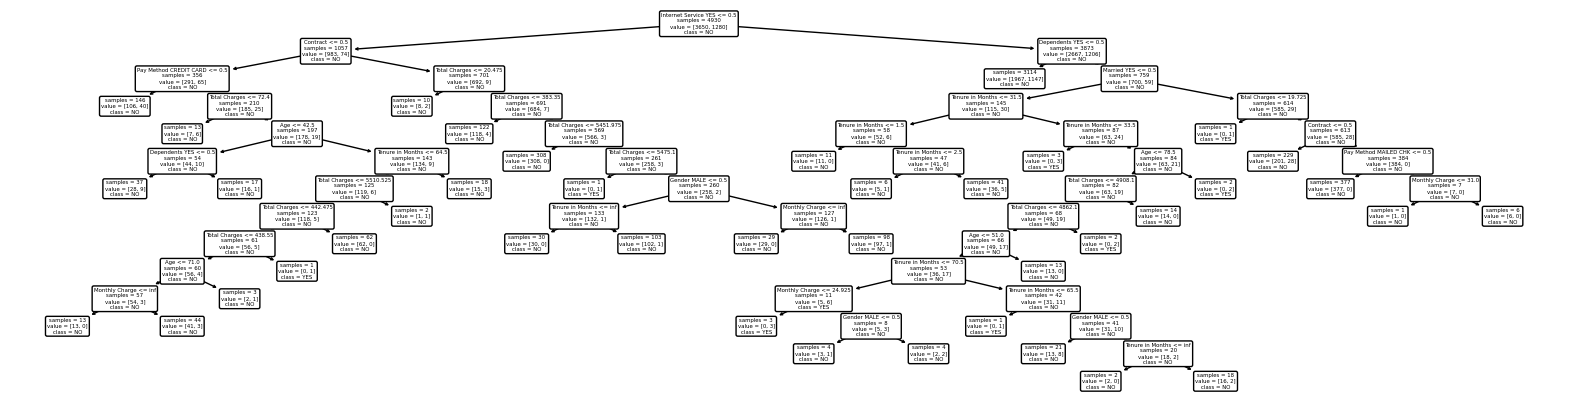

In [64]:
# Using plot_tree function to plot the decision tree.
fig, ax = plt.subplots(figsize=(20, 5))

plot_tree(
    churn_dt,
    feature_names=churn_df3a_X.columns.to_list(),
    class_names=["NO", "YES"],
    rounded=True,
    impurity=False,
    ax=ax,
    filled=False,  # True will color code nodes based on class
)

plt.show()

In [65]:
# Recall the TEST data
churn_df3b_X = churn_df3b.drop(["Churn"], axis=1)
churn_df3b_y = churn_df3b["Churn"]

In [66]:
# Scoring
train_score = churn_dt.score(churn_df3a_X, churn_df3a_y)
test_score = churn_dt.score(churn_df3b_X, churn_df3b_y)

print("Decision Tree Train Score:", train_score)
print("Decision Tree Test Score:", test_score)

Decision Tree Train Score: 0.7427991886409736
Decision Tree Test Score: 0.7203028868906768


Best test scores given by:
   Depth  Train Score  Test Score
9     10     0.835294    0.810696 




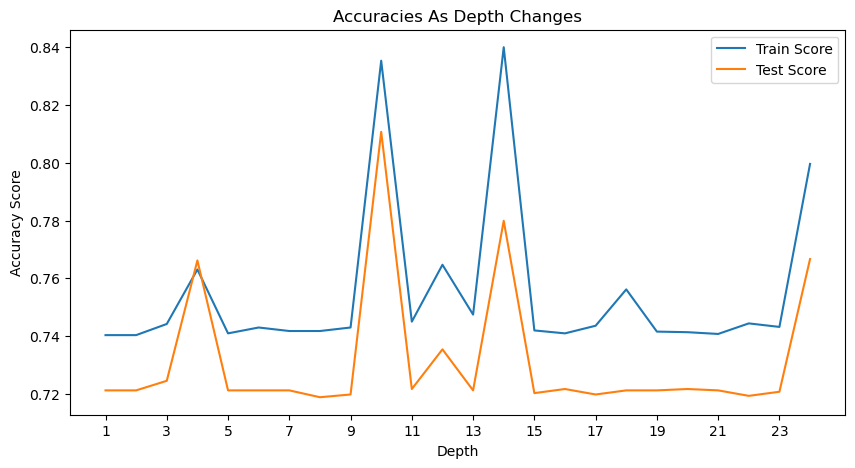

In [67]:
# Evaluate scores as tree depth changes
scores = pd.DataFrame()
depth_range = 25

# Loop through the max depth values
for max_depth in range(1, depth_range):
    churn_dt = DecisionTreeClassifier(max_depth=max_depth)
    churn_dt.fit(churn_df3a_X, churn_df3a_y)

    # Scoring
    train_score = churn_dt.score(churn_df3a_X, churn_df3a_y)
    test_score = churn_dt.score(churn_df3b_X, churn_df3b_y)

    # Append the results
    result = pd.DataFrame(
        {"Depth": [max_depth], "Train Score": [
            train_score], "Test Score": [test_score]}
    )
    scores = pd.concat([scores, result], axis=0, ignore_index=True)

# Best parameter
best_score = scores["Test Score"].max()
print("Best test scores given by:")
print(scores[scores["Test Score"] == best_score], "\n\n")

# Comparison plot
plt.figure(figsize=(10, 5))
plt.plot("Depth", "Train Score", data=scores)
plt.plot("Depth", "Test Score", data=scores)
plt.title("Accuracies As Depth Changes")
plt.xlabel("Depth")
plt.xticks(range(1, depth_range, 2))
plt.ylabel("Accuracy Score")
plt.legend()
plt.show()

In [68]:
# Regenerating the tree with optimal depth of 7
# Recall the TRAIN data
churn_df3a_X = churn_df3a.drop(["Churn"], axis=1)
churn_df3a_y = churn_df3a["Churn"]

# Instantiate & fit the decision tree
churn_dt7 = DecisionTreeClassifier(max_depth=7)
churn_dt7.fit(churn_df3a_X, churn_df3a_y)

# Generate the maximum depth
print("Maximum depth of tree:", churn_dt7.tree_.max_depth)

Maximum depth of tree: 7


In [69]:
# Scoring
train_score = churn_dt7.score(churn_df3a_X, churn_df3a_y)
test_score = churn_dt7.score(churn_df3b_X, churn_df3b_y)

print("Decision Tree Train Score:", train_score)
print("Decision Tree Test Score:", test_score)

Decision Tree Train Score: 0.7413793103448276
Decision Tree Test Score: 0.7203028868906768


###### NOTE:
###### The accuracy was different(!)
###### Could there be a missing parameter (like random state) that was assigned randomly?

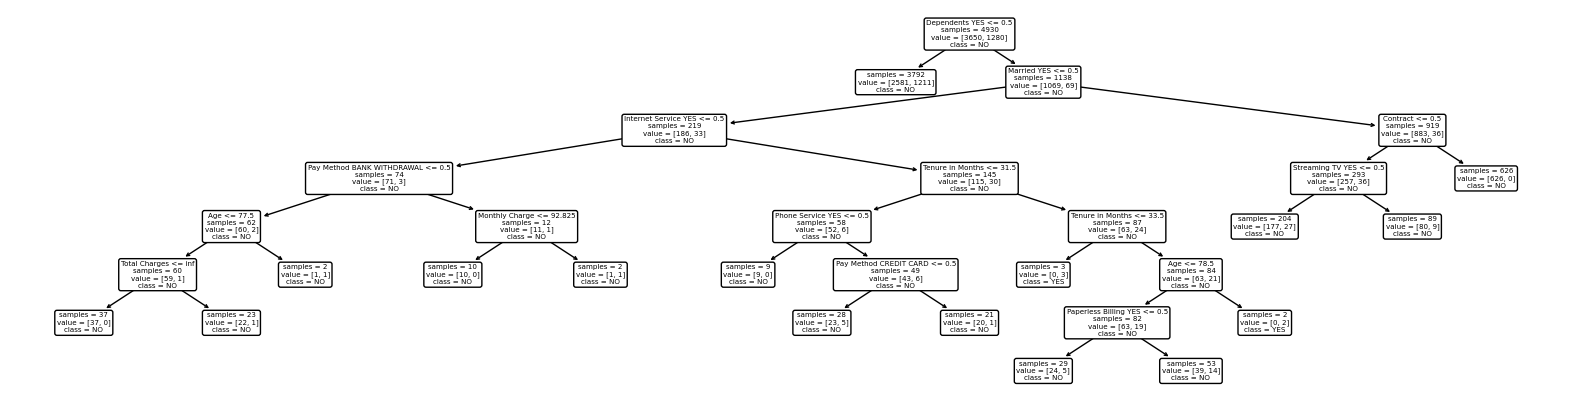

In [70]:
# Using plot_tree function to plot the decision tree.
fig, ax = plt.subplots(figsize=(20, 5))

plot_tree(
    churn_dt7,
    feature_names=churn_df3a_X.columns.to_list(),
    class_names=["NO", "YES"],
    rounded=True,
    impurity=False,
    ax=ax,
    filled=False,  # True will color code nodes based on class
)

plt.show()

### 4. MODEL EVALUATION

In [71]:
# Recall the TEST data
churn_df3b_X = churn_df3b.drop(["Churn"], axis=1)
churn_df3b_y = churn_df3b["Churn"]

# Get class predictions
y_pred = churn_dt7.predict(churn_df3b_X) 
y_test = churn_df3b_y

# Generate confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)

# Label rows and columns
cf_df = pd.DataFrame(
    cf_matrix,
    columns=["Predicted Non-fraudulent", "Predicted Fraudulent"],
    index=["True Non-fraudulent", "True Fraudulent"],
)

display(cf_df)

,Predicted Non-fraudulent,Predicted Fraudulent
True Non-fraudulent,1522,2
True Fraudulent,589,0


In [72]:
# Precision
# Code: precision_score(true labels, predicted labels)
print(f"The precision score is {precision_score(y_test, y_pred)}")

The precision score is 0.0


In [73]:
# Recall
# Code: recall_score(true labels, predicted labels)
print(f"The recall score is {recall_score(y_test, y_pred)}")

The recall score is 0.0


#### INTERPRETATION
###### Precision: Out of all the observations predicted to represent a churned customer, 50% of them actually churned.
###### Recall: Out of all churn cases, the model only correctly identified 0.34% of them(!)

In [74]:
# F1 score, harmonic mean of precision and recall scores, to maximize the precision and recall scores simultaneously
print(f"The f1 score is {f1_score(y_test, y_pred)}")

The f1 score is 0.0


In [75]:
# Printing classification report
report_initial = classification_report(y_test, y_pred)
print(report_initial)

              precision    recall  f1-score   support

           0       0.72      1.00      0.84      1524
           1       0.00      0.00      0.00       589

    accuracy                           0.72      2113
   macro avg       0.36      0.50      0.42      2113
weighted avg       0.52      0.72      0.60      2113



#### Receiver Operator Characteristic (ROC) Curve
###### The ROC is a graphical measure which compares the true positive and false positive rates of a binary model.

In [76]:
# Recall the TRAIN data
churn_df3a_X = churn_df3a.drop(["Churn"], axis=1) # "X_train"
churn_df3a_y = churn_df3a["Churn"] # "y_train"

# Class predictions
y_pred = churn_dt7.predict(churn_df3b_X) 
y_test = churn_df3b_y

In [77]:
# Recall the TEST data
churn_df3b_X = churn_df3b.drop(["Churn"], axis=1)
churn_df3b_y = churn_df3b["Churn"]

# Class predictions
y_pred = churn_dt7.predict(churn_df3b_X) 
y_test = churn_df3b_y

In [78]:
# Sklearn does not implement a False Positive Rate metric, so we have to write our own:
def false_positive_rate(y_true, y_pred):
    """Calculates the false positive rate (FPR) for binary classification.

    Args:
        y_true: A 1D array-like object containing the true labels (0 or 1).
        y_pred: A 1D array-like object containing the predicted labels (0 or 1).

    Returns:
        The false positive rate as a float.
    """

    # Find all values where y is negative + calculate total false positives
    false_positives = (y_true == 0) & (y_pred == 1)
    false_positive_number = false_positives.sum()

    # Find all values where y is negative + calculate total true negatives
    true_negatives = (y_true == 0) & (y_pred == 0)
    true_negative_number = true_negatives.sum()

    # Finally, find the ratio of (FP) to (TN + FP)
    FPR = false_positive_number / (true_negative_number + false_positive_number)

    return FPR

In [79]:
X_train = churn_df3a_X
y_train = churn_df3a_y

X_test = churn_df3b_X

# Get The probability for each point in the test set.
classifier = DecisionTreeClassifier(max_depth=7)
y_proba = classifier.fit(X_train, y_train).predict_proba(X_test)[:, 1]
thresholds = np.linspace(0, 1, 100)

# Iterate over the thresholds and compute the positive and negative recall
true_positive_rates = []
false_positive_rates = []

thresholds = np.linspace(0, 1, 50)
for threshold in thresholds:
    # Apply the cutoff and calculate the positive and negative recall
    y_pred = np.where(y_proba > threshold, 1, 0)

    tpr = recall_score(y_test, y_pred)
    fpr = false_positive_rate(y_test, y_pred)

    true_positive_rates.append(tpr)
    false_positive_rates.append(fpr)

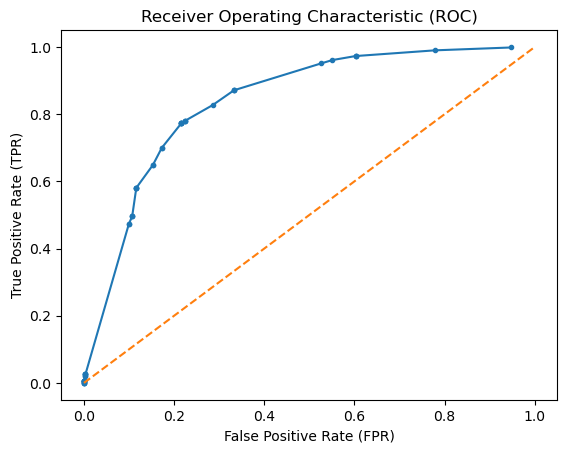

In [80]:
# ROC curve
# True positive rate (TPR) = recall
tp_rate = np.array(true_positive_rates)

# False positive rate (FPR)
fp_rate = np.array(false_positive_rates)

plt.figure()

plt.plot(fp_rate, tp_rate, marker=".")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Receiver Operating Characteristic (ROC)")

plt.show()

###### Each point on the curve represents a trade-off between true and false positive rates.
###### The model is useful for tuning acceptance thresholds.

### 5. CONCLUSIONS

###### 1. As suspected from the feature selection analysis, any model with the available features would be lacking.
###### 2. Eventually, no features were removed from the model. Only three features had a variance and target correlation high enough to justify inclusion, and removing all the others ones would arguably remove too much data.
###### 3. The model could be improved by getting more valid features, such as those capturing changes in service quality, pricing, or product offered.
###### 4. Perhaps harder to represent as data, but insightful, would be what competitors are offering. 